<!-- importing the required libraries -->

In [4]:
import pandas as pd

from naive_bayes import NaiveBayesClassifier
from train_model import load_dataset, prepare_text, TRAIN_RATIO, SEED


<!-- Loading the saved model -->

In [5]:
MODEL_PATH = r"C:\Users\apeks\OneDrive\Desktop\Seventh\Project\resumeParser\resume_parser\media\models\naive_bayes_model.pkl"

model = NaiveBayesClassifier()
model.load_model(MODEL_PATH)

print(f"Trained: {model.trained}")
print(f"Classes: {len(model.class_priors)}")
print(f"Vocabulary size: {len(model.vocabulary)}")


Trained: True
Classes: 151
Vocabulary size: 2326


In [6]:
import random

DATASET_PATH = r"C:\Users\apeks\OneDrive\Desktop\Seventh\Project\resumeParser\resume_parser\datasets\Ndataset.csv"

rows = load_dataset(DATASET_PATH)
random.seed(SEED)
random.shuffle(rows)

split = int(len(rows) * TRAIN_RATIO)
test_rows = rows[split:]

X_test = [prepare_text(r) for r in test_rows]
y_test = [r["job_category"] for r in test_rows]

print(f"Test samples: {len(X_test)}")


Test samples: 5020


<!-- Run predictions -->

In [7]:
predictions = model.predict(X_test)
y_pred = [p["label"] for p in predictions]


<!-- Calculating accuracy, precision, recall and f1-score -->

In [14]:
from collections import Counter

correct = sum(a == b for a, b in zip(y_test, y_pred))
accuracy = correct / len(y_test)

classes = sorted(set(y_test) | set(y_pred))
tp, fp, fn, support = Counter(), Counter(), Counter(), Counter()

for actual, pred in zip(y_test, y_pred):
    support[actual] += 1
    if actual == pred:
        tp[actual] += 1
    else:
        fp[pred] += 1
        fn[actual] += 1

per_class = {}
for c in classes:
    prec = tp[c] / (tp[c] + fp[c]) if (tp[c] + fp[c]) > 0 else 0.0
    rec = tp[c] / (tp[c] + fn[c]) if (tp[c] + fn[c]) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    per_class[c] = {"precision": prec, "recall": rec, "f1": f1, "support": support[c]}

macro_precision = sum(v["precision"] for v in per_class.values()) / len(per_class)
macro_recall = sum(v["recall"] for v in per_class.values()) / len(per_class)
macro_f1 = sum(v["f1"] for v in per_class.values()) / len(per_class)

total_support = sum(support.values())
weighted_precision = sum(v["precision"] * v["support"] for v in per_class.values()) / total_support
weighted_recall = sum(v["recall"] * v["support"] for v in per_class.values()) / total_support
weighted_f1 = sum(v["f1"] * v["support"] for v in per_class.values()) / total_support

summary = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1",
               "Weighted Precision", "Weighted Recall", "Weighted F1"],
    "Score": [accuracy, macro_precision, macro_recall, macro_f1,
              weighted_precision, weighted_recall, weighted_f1],
})
summary["Score"] = summary["Score"].round(4)
summary


,Metric,Score
0,Accuracy,0.7020
1,Macro Precision,0.7099
2,Macro Recall,0.6972
3,Macro F1,0.6908
4,Weighted Precision,0.7217
5,Weighted Recall,0.7020
6,Weighted F1,0.6989


<!-- Job Category information -->

In [9]:
per_class_df = pd.DataFrame([
    {"job_category": c, "precision": round(v["precision"], 3), "recall": round(v["recall"], 3),
     "f1": round(v["f1"], 3), "support": v["support"]}
    for c, v in per_class.items()
]).sort_values("f1", ascending=False).reset_index(drop=True)

per_class_df


,job_category,precision,recall,f1,support
0,CTO (Chief Technology Officer),1.000,1.000,1.000,28
1,Documentation Engineer,1.000,1.000,1.000,27
2,Digital Marketing Executive,1.000,1.000,1.000,33
3,Web Analyst,1.000,1.000,1.000,36
4,Engineering Manager,1.000,1.000,1.000,35
...,...,...,...,...,...
146,Java Developer,0.353,0.171,0.231,35
147,Laravel Developer,0.182,0.250,0.211,24
148,IoT Developer,0.250,0.167,0.200,24
149,Angular Developer,0.167,0.100,0.125,30


<!-- Confusion Matrix is calculated and saved as a different csv file -->

In [10]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

classes_sorted = sorted(classes)
idx = {c: i for i, c in enumerate(classes_sorted)}
n = len(classes_sorted)

cm = np.zeros((n, n), dtype=int)
for a, p in zip(y_test, y_pred):
    cm[idx[a], idx[p]] += 1

cm_df = pd.DataFrame(cm, index=classes_sorted, columns=classes_sorted)
cm_df.to_csv("confusion_matrix_full.csv")
print(f"Full confusion matrix: {n} x {n}, saved to confusion_matrix_full.csv")


Full confusion matrix: 151 x 151, saved to confusion_matrix_full.csv


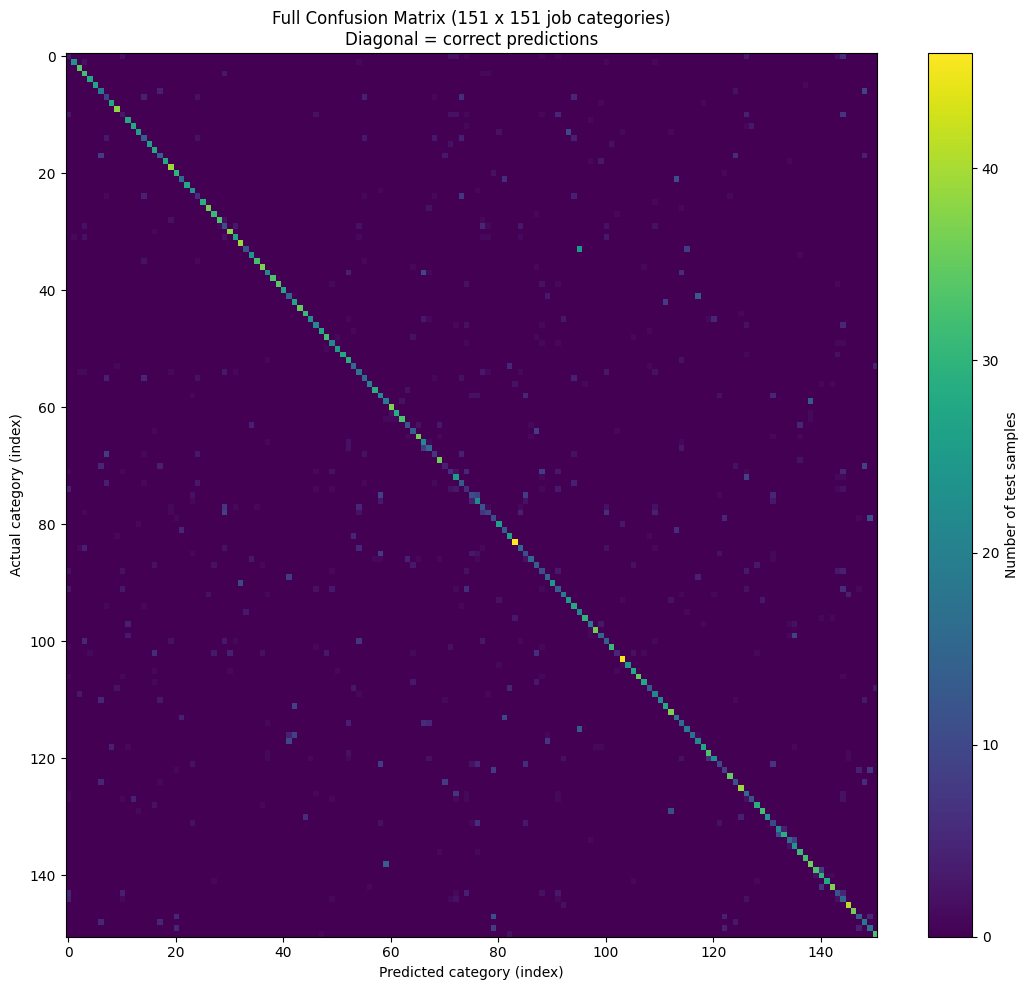

In [11]:
plt.figure(figsize=(11, 10))
plt.imshow(cm, cmap="viridis", aspect="auto")
plt.colorbar(label="Number of test samples")
plt.title("Full Confusion Matrix (151 x 151 job categories)\nDiagonal = correct predictions")
plt.xlabel("Predicted category (index)")
plt.ylabel("Actual category (index)")
plt.tight_layout()
plt.show()


<!-- Displays the most frequently confused categories by showing their row-normalized misclassification counts, with the diagonal representing recall for each category. -->

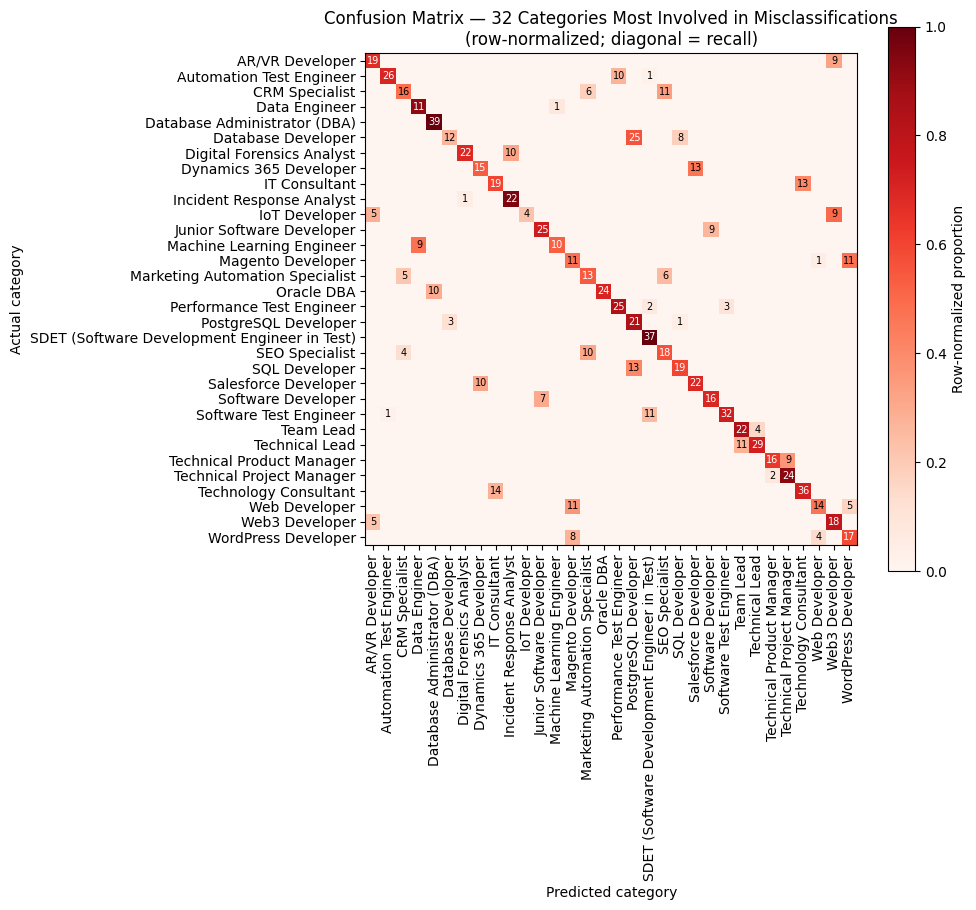

In [12]:
confusion_pairs = Counter()
for actual, pred in zip(y_test, y_pred):
    if actual != pred:
        confusion_pairs[(actual, pred)] += 1

TOP_N_PAIRS = 20
top_pairs = confusion_pairs.most_common(TOP_N_PAIRS)

involved = set()
for (a, p), _ in top_pairs:
    involved.add(a)
    involved.add(p)
involved = sorted(involved)

sub_idx = {c: i for i, c in enumerate(involved)}
m = len(involved)
sub_cm = np.zeros((m, m), dtype=int)
for a, p in zip(y_test, y_pred):
    if a in sub_idx and p in sub_idx:
        sub_cm[sub_idx[a], sub_idx[p]] += 1

row_sums = sub_cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
sub_cm_norm = sub_cm / row_sums

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(sub_cm_norm, cmap="Reds", vmin=0, vmax=1)
ax.set_xticks(range(m))
ax.set_yticks(range(m))
ax.set_xticklabels(involved, rotation=90)
ax.set_yticklabels(involved)
ax.set_xlabel("Predicted category")
ax.set_ylabel("Actual category")
ax.set_title(f"Confusion Matrix — {m} Categories Most Involved in Misclassifications\n(row-normalized; diagonal = recall)")

for i in range(m):
    for j in range(m):
        if sub_cm[i, j] > 0:
            color = "white" if sub_cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, int(sub_cm[i, j]), ha="center", va="center", color=color, fontsize=7)

plt.colorbar(im, label="Row-normalized proportion")
plt.tight_layout()
plt.show()
